<center><font size=15>Chest X-Ray Pneumonia Detection Using Deep Learning</center></font>

<center><p float="center">
  <img src="https://www.news-medical.net/image-handler/picture/2021/5/shutterstock_1160251117.jpg" width=720></a>
<center><font size=6>Bacterial Pneumonia</center></font>

# **About Pneumonia**

Pneumonia is a lung infection that causes the air sacs in the lungs to fill with fluid or pus, making it difficult to breathe.

It can be caused by bacteria, viruses, or fungi and is commonly diagnosed using chest X-ray images.

## **Project Objective**

The objective of this project is to develop a deep learning model that can automatically detect pneumonia from chest X-ray images. The model classifies X-ray images into two categories: **Normal** and **Pneumonia**, helping to assist in the early detection of lung infections.

In [2]:
## Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import required libraries

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [4]:
## Define Dataset Paths
train_dir = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/train"
test_dir = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/test"
val_dir = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/val"

# **Dataset Understanding (EDA)**

In [6]:
#Check folder structure
print(os.listdir(train_dir))

['NORMAL', 'PNEUMONIA']


In [5]:
#Count images in each class
folders = {
    "Train": train_dir,
    "Validation": val_dir,
    "Test": test_dir
}

for name, path in folders.items():

    normal = len(os.listdir(path + "/NORMAL"))
    pneumonia = len(os.listdir(path + "/PNEUMONIA"))

    print(name)
    print("NORMAL:", normal)
    print("PNEUMONIA:", pneumonia)
    print("Total:", normal+pneumonia)
    print("----------------")

Train
NORMAL: 304
PNEUMONIA: 905
Total: 1209
----------------
Validation
NORMAL: 9
PNEUMONIA: 9
Total: 18
----------------
Test
NORMAL: 234
PNEUMONIA: 284
Total: 518
----------------


# Visualize Class Distribution

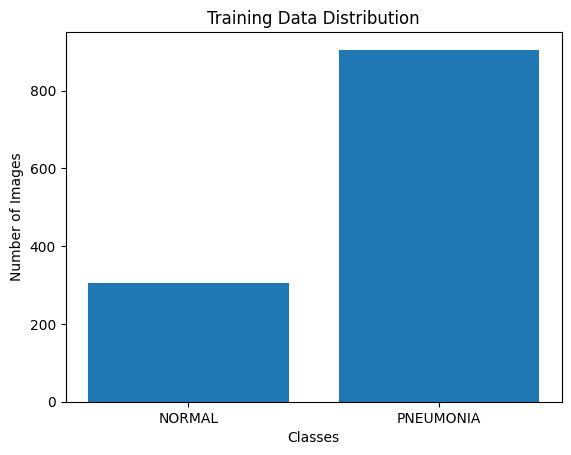

In [7]:
train_counts = {
    "NORMAL": len(os.listdir(train_dir+"/NORMAL")),
    "PNEUMONIA": len(os.listdir(train_dir+"/PNEUMONIA"))
}

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Data Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

The dataset contains more PNEUMONIA images than NORMAL images. This shows that the training data is not balanced, which may affect the model's learning and prediction performance.

# **Display Sample X-Ray Images**

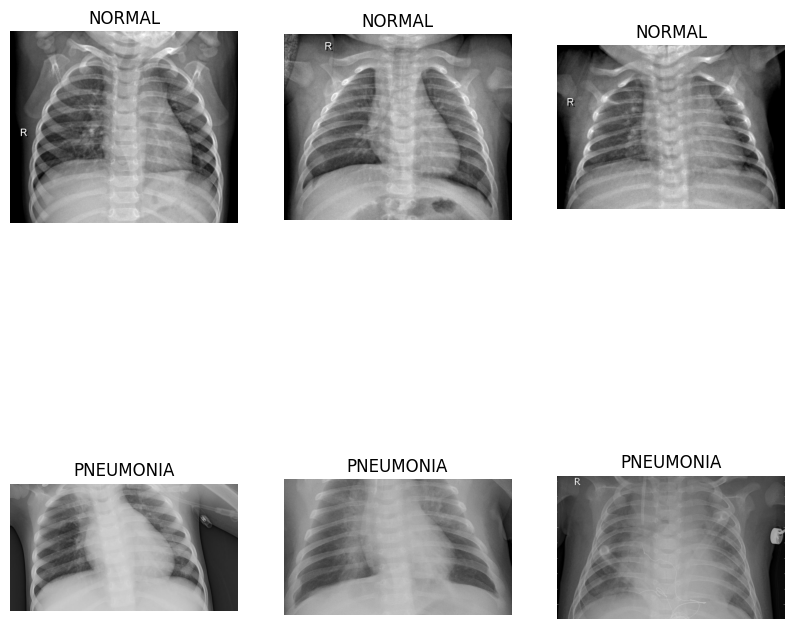

In [8]:
import random
import matplotlib.image as mpimg


plt.figure(figsize=(10,10))

normal_images = os.listdir(train_dir+"/NORMAL")
pneumonia_images = os.listdir(train_dir+"/PNEUMONIA")


for i in range(3):

    img_path = train_dir+"/NORMAL/"+random.choice(normal_images)

    img = mpimg.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")


for i in range(3):

    img_path = train_dir+"/PNEUMONIA/"+random.choice(pneumonia_images)

    img = mpimg.imread(img_path)

    plt.subplot(2,3,i+4)
    plt.imshow(img,cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.show()

# **Data Preprocessing**

In [9]:
#Image Parameters
IMG_SIZE = 224
BATCH_SIZE = 32

Data Augmentation

In [10]:
#For training images:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True)

In [12]:
#For validation and testing:
test_datagen = ImageDataGenerator(
    rescale=1./255)

# Load Images

In [13]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1207 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 518 images belonging to 2 classes.


In [14]:
#Check labels
print(train_data.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data.classes
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(1.9917491749174918), np.int64(1): np.float64(0.6675884955752213)}


# **Build CNN Model**

In [17]:
model = Sequential([
Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
MaxPooling2D(2,2),
Conv2D(64,(3,3),activation="relu"),
MaxPooling2D(2,2),
Conv2D(128,(3,3),activation="relu"),
MaxPooling2D(2,2),
Flatten(),
Dense(128,activation="relu"),
Dropout(0.5),
Dense(1,activation="sigmoid")])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 272s 7s/step - accuracy: 0.6578 - loss: 0.6683 - val_accuracy: 0.8125 - val_loss: 0.4259
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8086 - loss: 0.4076 - val_accuracy: 0.8125 - val_loss: 0.4339
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8459 - loss: 0.3390 - val_accuracy: 0.8125 - val_loss: 0.3824
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8376 - loss: 0.3405 - val_accuracy: 0.7500 - val_loss: 0.5342
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.8509 - loss: 0.3261 - val_accuracy: 0.5625 - val_loss: 0.6462
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8940 - loss: 0.2739 - val_accuracy: 0.7500 - val_loss: 0.5804
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.8865 - loss: 0.2691 - val_accuracy: 0.7500 - val_loss: 0.5683
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8890 - loss: 0.2440 - val_accuracy: 0.8125 - val_lo

Model Evaluation

In [20]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:",accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 126s 8s/step - accuracy: 0.8456 - loss: 0.5517
Test Accuracy: 0.84555983543396


# Performance **Visualization**

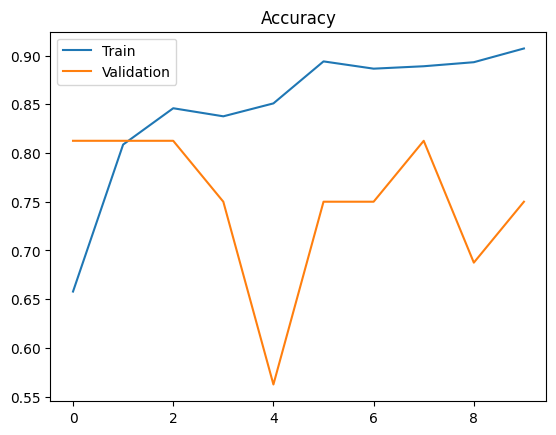

In [21]:
#Accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

The training accuracy keeps increasing, but the validation accuracy decreases after a few epochs. This means the model is overfitting. It learns the training data well but does not perform as well on new (validation) data.

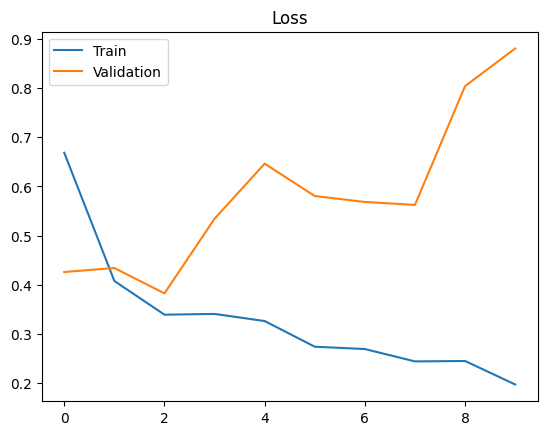

In [22]:
#Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [23]:
#Save Model
model.save("pneumonia_model.keras")

#**Improved CNN**
This model has an extra convolution layer and Batch Normalization.

In [24]:
from tensorflow.keras.layers import BatchNormalization

model2 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,033 (37.49 MB)

 Trainable params: 9,827,073 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
#compile
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
# Train

history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.8244 - loss: 3.2853 - val_accuracy: 0.5000 - val_loss: 14.2705
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step - accuracy: 0.8840 - loss: 0.8602 - val_accuracy: 0.5000 - val_loss: 44.3556
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.8890 - loss: 0.4444 - val_accuracy: 0.5000 - val_loss: 40.4924
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 210s 4s/step - accuracy: 0.9114 - loss: 0.3708 - val_accuracy: 0.5000 - val_loss: 87.6815
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.9031 - loss: 0.4146 - val_accuracy: 0.5625 - val_loss: 74.5543
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.8956 - loss: 0.2925 - val_accuracy: 0.5000 - val_loss: 196.7619
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.9163 - loss: 0.2308 - val_accuracy: 0.5000 - val_loss: 137.1068
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.9114 - loss: 0.2210 - val_accuracy: 0

#**MobileNetV2 (Transfer Learning)**

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model3 = Model(inputs=base_model.input, outputs=output)

model3.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
#compile
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6504 - loss: 0.6666 - val_accuracy: 0.8125 - val_loss: 0.4940
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7871 - loss: 0.4491 - val_accuracy: 0.8125 - val_loss: 0.4181
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8500 - loss: 0.3397 - val_accuracy: 0.8125 - val_loss: 0.3980
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8426 - loss: 0.3164 - val_accuracy: 0.6875 - val_loss: 0.4488
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8815 - loss: 0.2734 - val_accuracy: 0.6875 - val_loss: 0.4666
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8799 - loss: 0.2618 - val_accuracy: 0.6875 - val_loss: 0.4406
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8973 - loss: 0.2362 - val_accuracy: 0.6875 - val_loss: 0.4511
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9014 - loss: 0.2248 - val_accuracy: 0.7500 - val_loss:

Evaluate All Models

In [30]:
loss1, acc1 = model.evaluate(test_data)
loss2, acc2 = model2.evaluate(test_data)
loss3, acc3 = model3.evaluate(test_data)

print("Model 1 Accuracy:", acc1)
print("Model 2 Accuracy:", acc2)
print("Model 3 Accuracy:", acc3)

17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8456 - loss: 0.5517
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 927ms/step - accuracy: 0.5483 - loss: 95.1843
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 966ms/step - accuracy: 0.8224 - loss: 0.3973
Model 1 Accuracy: 0.84555983543396
Model 2 Accuracy: 0.5482625365257263
Model 3 Accuracy: 0.8223938345909119


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

test_data.reset()

predictions = model.predict(test_data)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 752ms/step
              precision    recall  f1-score   support

      NORMAL       0.92      0.72      0.81       234
   PNEUMONIA       0.81      0.95      0.87       284

    accuracy                           0.85       518
   macro avg       0.86      0.83      0.84       518
weighted avg       0.86      0.85      0.84       518

Confusion Matrix:
[[169  65]
 [ 15 269]]


# **Compare Results**

In [32]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Basic CNN", "Improved CNN", "MobileNetV2"],
    "Test Accuracy": [acc1, acc2, acc3]
})

print(results)

          Model  Test Accuracy
0     Basic CNN       0.845560
1  Improved CNN       0.548263
2   MobileNetV2       0.822394


# **Save the Best Model**

In [33]:
#Save the Best Model(Model1)
model.save("pneumonia_model.keras")

# **Prediciton**

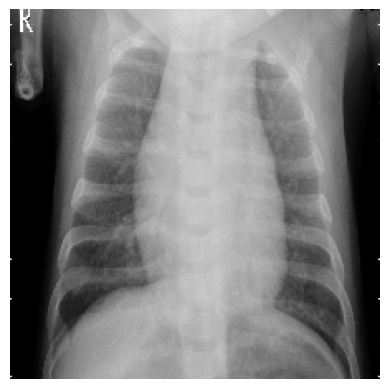

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Prediction: PNEUMONIA
Confidence: 99.92 %


In [34]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("pneumonia_model.keras")

# Path of the test image
img_path = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/test/PNEUMONIA/person1653_virus_2858.jpeg"

# Load and display the image
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess the image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Display result
if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
    print("Confidence:", round(prediction[0][0] * 100, 2), "%")
else:
    print("Prediction: NORMAL")
    print("Confidence:", round((1 - prediction[0][0]) * 100, 2), "%")


# **Conclusion**

Three models were evaluated for pneumonia detection: **Basic CNN, Improved CNN, and MobileNetV2 using transfer learning**. The training data had class imbalance, so **balanced class weights** were used during model training to give more importance to the minority class.

Among the evaluated models, the **Basic CNN achieved the highest test accuracy of 84.56%**. It also achieved **95% recall for the Pneumonia class**, showing that the model was able to correctly identify most pneumonia cases in the test set. Precision, recall, F1-score, and the confusion matrix were also used to evaluate the model beyond accuracy.

Based on these experimental results, the **Basic CNN was selected as the final model** and saved as `pneumonia_model.keras` for making predictions through the application.
